# Setup

## Imports and Configuration

In [19]:
# If file is stored on Drive...
from google.colab import drive
drive.mount('/content/drive')

import csv

import matplotlib.pyplot as plt
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Path to files
baseline_results_dir = "/content/drive/My Drive/EECS 6412 - Project/3. Solution & Final Report/2. Evaluation/Baseline Results/"
solution_results_dir = "/content/drive/My Drive/EECS 6412 - Project/3. Solution & Final Report/2. Evaluation/Baseline Results/"
# solution_results_dir = "/content/drive/My Drive/EECS 6412 - Project/3. Solution & Final Report/2. Evaluation/Our Results/"

baseline_results_filename = "baseline_results.csv"
solution_results_filename = "solution_results_dummy.csv"
# solution_results_filename = "solution_results.csv"

In [53]:
# Configuration for plots
BENCHMARK_CODE_TO_NAME = {"dmu": "DMU", "ta": "Taillard"}
PLOT_TITLE_FORMAT = "Gap for {benchmark_name} Instances: J={num_jobs}, M={num_machines}"
PLOT_YAXIS = "Gap Percentage (%)"
PLOT_XAXIS = "Instance"
FIGSIZE = (12, 4)
SAVE_DIR = "/content/drive/My Drive/EECS 6412 - Project/3. Solution & Final Report/2. Evaluation/Comparison/"

## Import the two files

In [5]:
def get_results(results_file):
    results = {}

    with open(results_file, mode ='r') as results_file:
        results_reader = csv.DictReader(results_file)
        for instance in results_reader:
            if instance["gap"] != '-':
                results[instance["instance"]] = {
                    "gap": round( float( instance["gap"].strip('%') )/100, 3 ),
                    "num_jobs": instance["j"],
                    "num_machines": instance["m"]
                }

    return results

In [6]:
baseline_results = get_results(baseline_results_dir + baseline_results_filename)
solution_results = get_results(solution_results_dir + solution_results_filename)
# print(baseline_results)         # Should show all instances
# print(len(baseline_results))    # Should be 130
# print(solution_results)         # Should show all instances
# print(len(solution_results))    # Should be 130

# Plotting both results

In [7]:
baseline_results

{'dmu01': {'gap': 0.195, 'num_jobs': '20', 'num_machines': '15'},
 'dmu02': {'gap': 0.178, 'num_jobs': '20', 'num_machines': '15'},
 'dmu03': {'gap': 0.226, 'num_jobs': '20', 'num_machines': '15'},
 'dmu04': {'gap': 0.201, 'num_jobs': '20', 'num_machines': '15'},
 'dmu05': {'gap': 0.23, 'num_jobs': '20', 'num_machines': '15'},
 'dmu06': {'gap': 0.21, 'num_jobs': '20', 'num_machines': '20'},
 'dmu07': {'gap': 0.146, 'num_jobs': '20', 'num_machines': '20'},
 'dmu08': {'gap': 0.247, 'num_jobs': '20', 'num_machines': '20'},
 'dmu09': {'gap': 0.22, 'num_jobs': '20', 'num_machines': '20'},
 'dmu10': {'gap': 0.236, 'num_jobs': '20', 'num_machines': '20'},
 'dmu11': {'gap': 0.288, 'num_jobs': '30', 'num_machines': '15'},
 'dmu12': {'gap': 0.243, 'num_jobs': '30', 'num_machines': '15'},
 'dmu13': {'gap': 0.26, 'num_jobs': '30', 'num_machines': '15'},
 'dmu14': {'gap': 0.16, 'num_jobs': '30', 'num_machines': '15'},
 'dmu15': {'gap': 0.221, 'num_jobs': '30', 'num_machines': '15'},
 'dmu16': {'gap

In [8]:
solution_results

{'dmu01': {'gap': 0.195, 'num_jobs': '20', 'num_machines': '15'},
 'dmu02': {'gap': 0.178, 'num_jobs': '20', 'num_machines': '15'},
 'dmu03': {'gap': 0.226, 'num_jobs': '20', 'num_machines': '15'},
 'dmu04': {'gap': 0.201, 'num_jobs': '20', 'num_machines': '15'},
 'dmu05': {'gap': 0.23, 'num_jobs': '20', 'num_machines': '15'},
 'dmu06': {'gap': 0.21, 'num_jobs': '20', 'num_machines': '20'},
 'dmu07': {'gap': 0.146, 'num_jobs': '20', 'num_machines': '20'},
 'dmu08': {'gap': 0.247, 'num_jobs': '20', 'num_machines': '20'},
 'dmu09': {'gap': 0.22, 'num_jobs': '20', 'num_machines': '20'},
 'dmu10': {'gap': 0.236, 'num_jobs': '20', 'num_machines': '20'},
 'dmu11': {'gap': 0.288, 'num_jobs': '30', 'num_machines': '15'},
 'dmu12': {'gap': 0.243, 'num_jobs': '30', 'num_machines': '15'},
 'dmu13': {'gap': 0.26, 'num_jobs': '30', 'num_machines': '15'},
 'dmu14': {'gap': 0.16, 'num_jobs': '30', 'num_machines': '15'},
 'dmu15': {'gap': 0.221, 'num_jobs': '30', 'num_machines': '15'},
 'dmu16': {'gap

In [9]:
# First, determine the set of Job x Machine combinations that we have results for
jm_combos_by_benchmark = {}

# Iterate over the baseline results dictionary
for k, v in baseline_results.items():
    benchmark = k[:-2]
    existing_combos = jm_combos_by_benchmark.get(benchmark)
    if not existing_combos:
        jm_combos_by_benchmark[benchmark] = []
        existing_combos = []

    this_combo = (v['num_jobs'], v['num_machines'])
    if not this_combo in existing_combos:
        jm_combos_by_benchmark[benchmark].append(this_combo)

In [10]:
jm_combos_by_benchmark

{'dmu': [('20', '15'),
  ('20', '20'),
  ('30', '15'),
  ('30', '20'),
  ('40', '15'),
  ('40', '20'),
  ('50', '15')],
 'ta': [('15', '15'),
  ('20', '15'),
  ('20', '20'),
  ('30', '15'),
  ('30', '20'),
  ('50', '15'),
  ('50', '20')]}

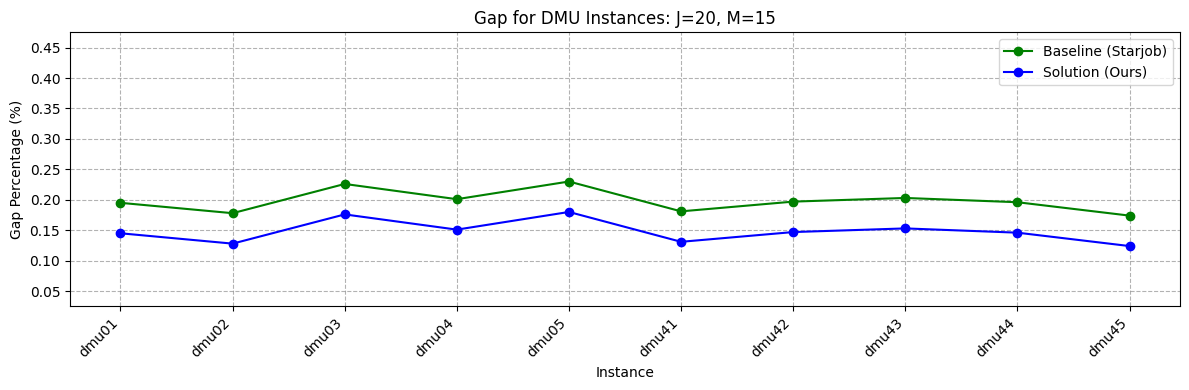

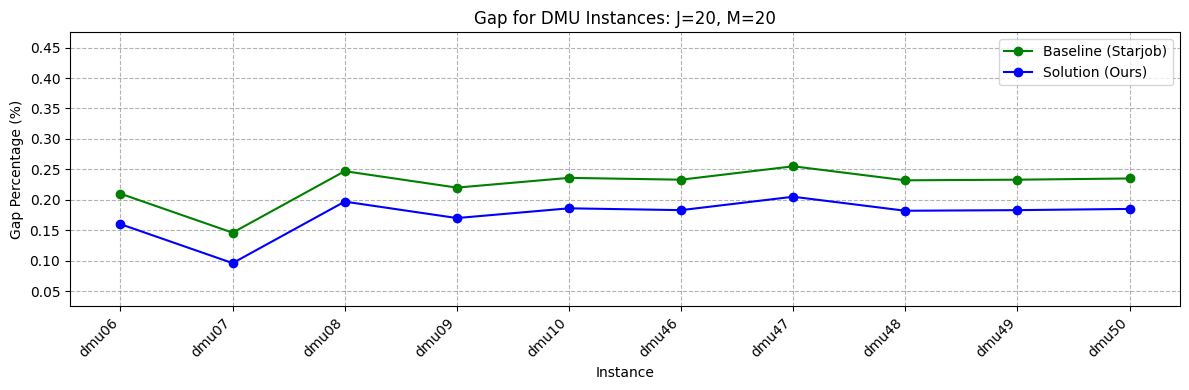

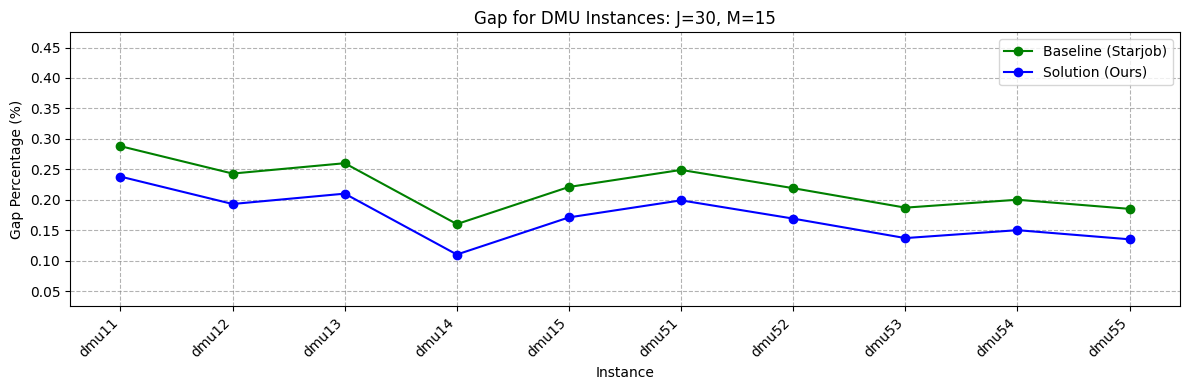

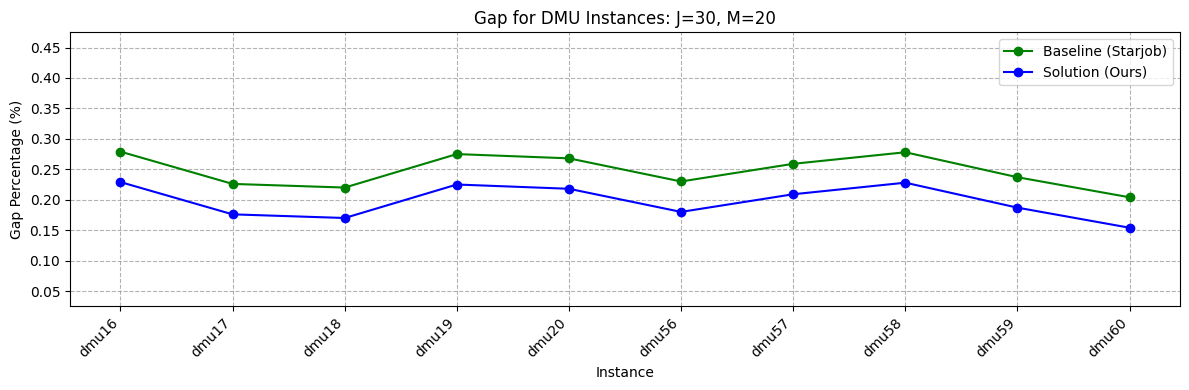

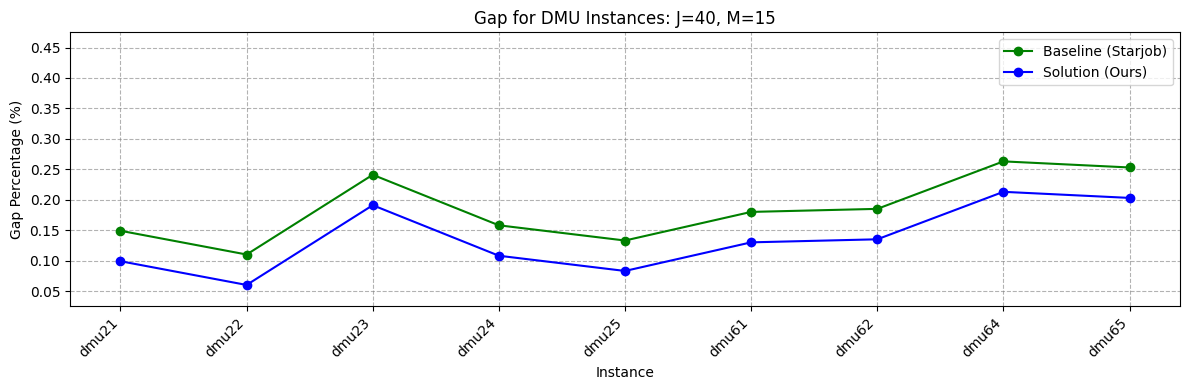

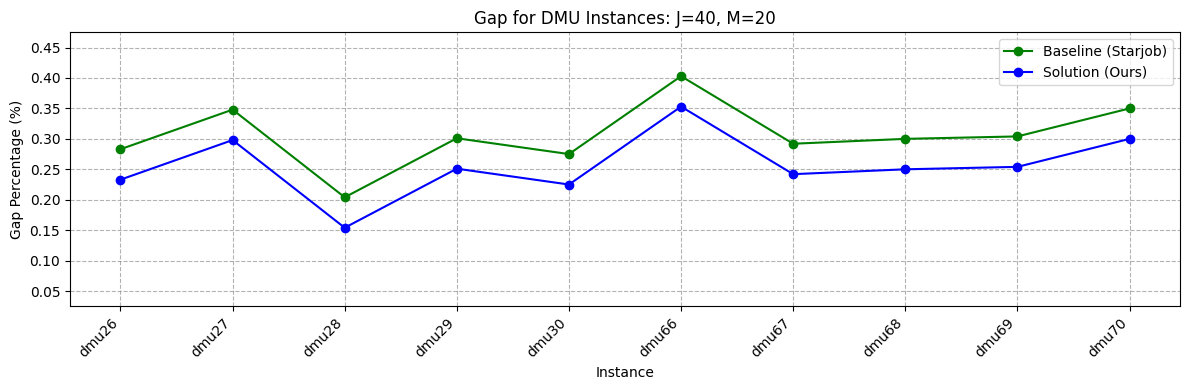

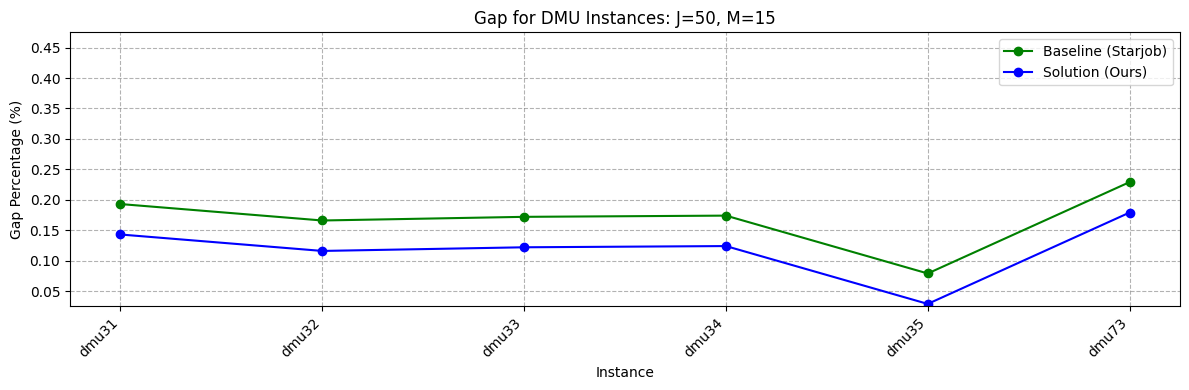

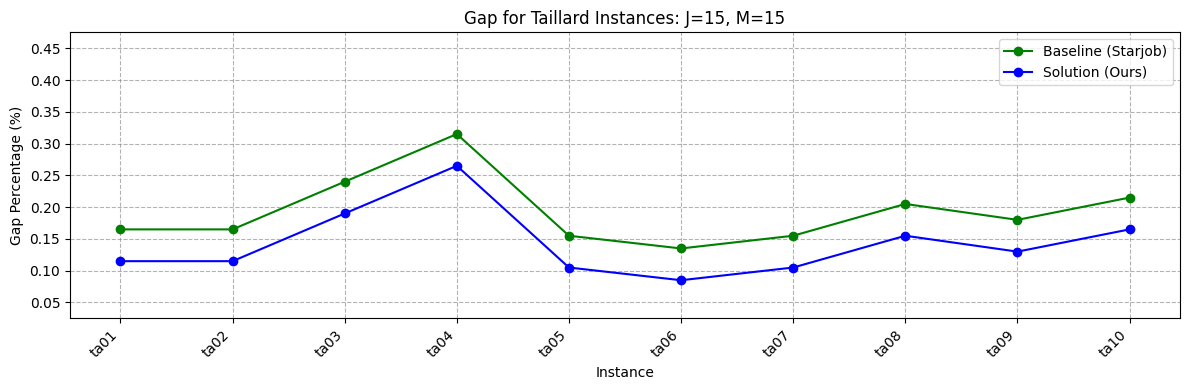

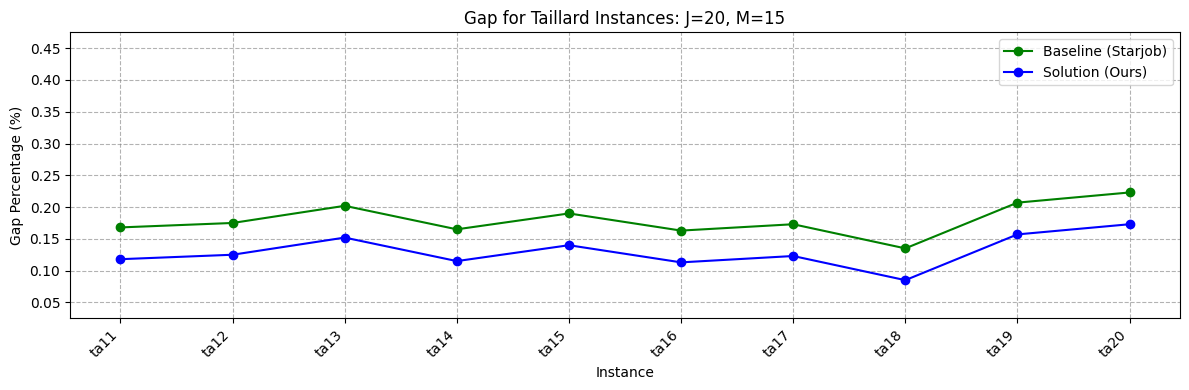

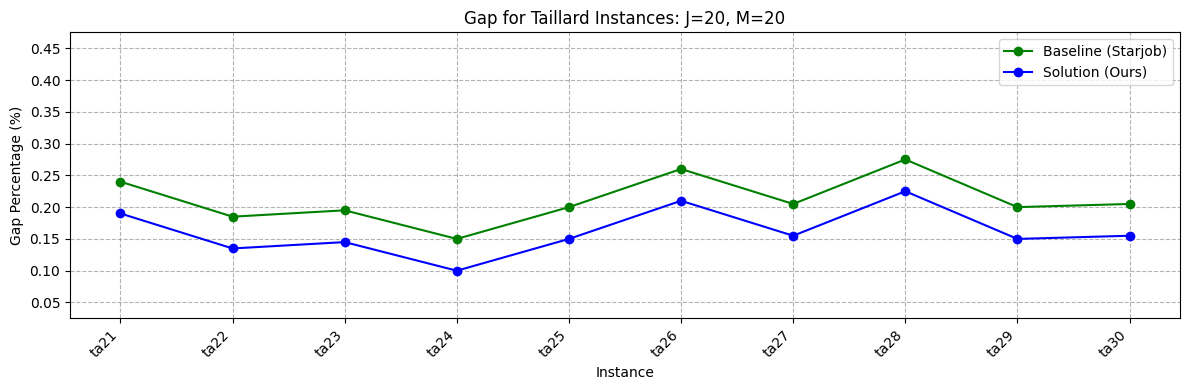

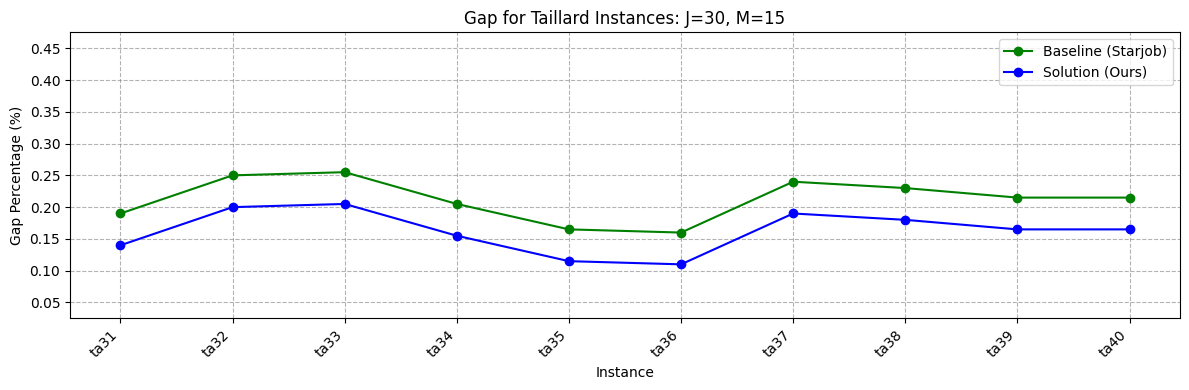

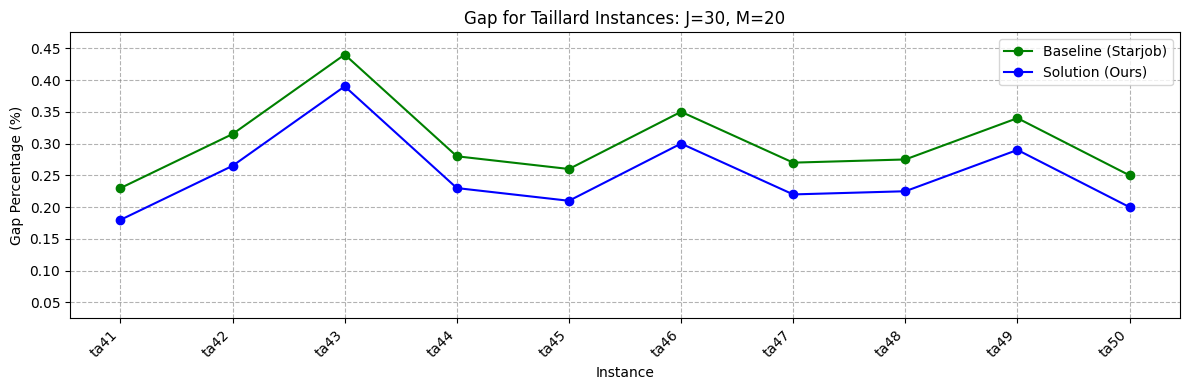

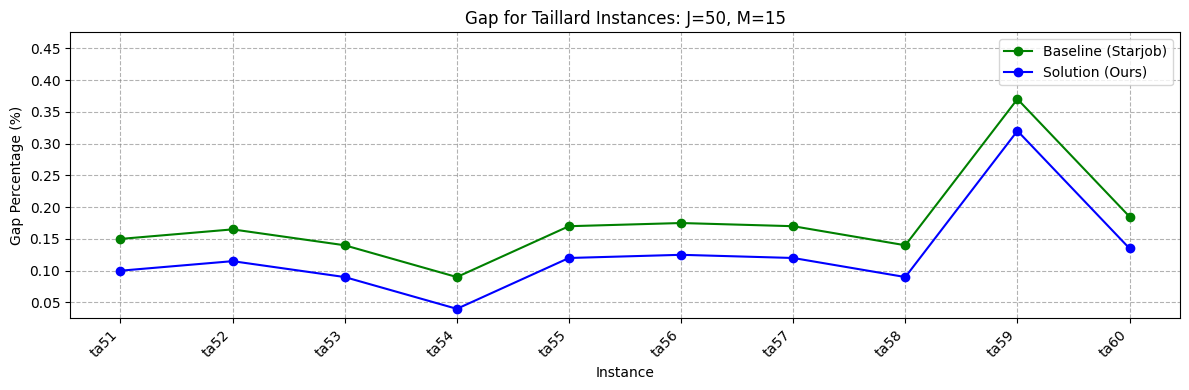

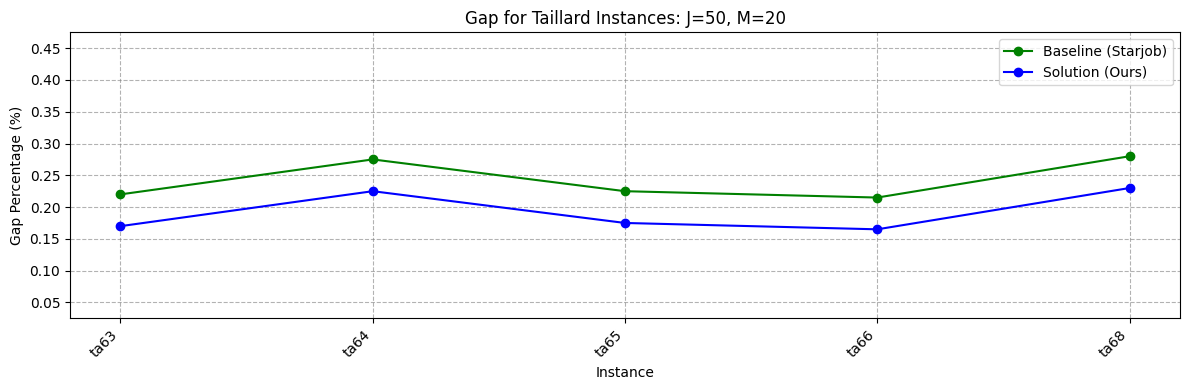

In [55]:
# Then create plots for each Job x Machine combo
for benchmark, jm_combos in jm_combos_by_benchmark.items():
    benchmark_name = BENCHMARK_CODE_TO_NAME[benchmark]
    for jm_combo in jm_combos:
        # Select the results for this specific combo
        num_jobs, num_machines = jm_combo
        combo_results_baseline = {
                                    bm: res["gap"] for bm, res in baseline_results.items()
                                    if bm[:-2] == benchmark and
                                    num_jobs == res["num_jobs"] and
                                    num_machines == res["num_machines"]
                                }
        combo_results_solution = {
                                    bm: res["gap"] for bm, res in solution_results.items()
                                    if bm[:-2] == benchmark and
                                    num_jobs == res["num_jobs"] and
                                    num_machines == res["num_machines"]
                                }

        # Prepare the plot for this combo
        plt.figure(figsize=FIGSIZE)

        # Plotted points
        x = np.arange(len(combo_results_baseline))
        plt.plot(x, combo_results_baseline.values(), color="green", marker="o", label="Baseline (Starjob)")
        plt.plot(x, combo_results_solution.values(), color="blue", marker="o", label="Solution (Ours)")

        # X-axis
        plt.xlabel(PLOT_XAXIS)
        plt.xticks(x, combo_results_baseline.keys(), rotation=45, ha="right")

        # Y-axis
        plt.ylabel(PLOT_YAXIS)
        plt.ylim(0.025, 0.475)

        # Title
        title = PLOT_TITLE_FORMAT.format(benchmark_name = benchmark_name,
                                         num_jobs = num_jobs, num_machines = num_machines)
        plt.title(title)

        # Grid (dashed, light gray)
        plt.grid(axis="x", linestyle="--", color="gray", alpha=0.6)
        plt.grid(axis="y", linestyle="--", color="gray", alpha=0.6)

        # Legend
        plt.legend(loc="upper right")

        # Plot is ready, save and display it
        plt.tight_layout()
        plt.savefig(f"{SAVE_DIR}/{benchmark}_{num_jobs}x{num_machines}.png")
        plt.show()
